# Feature-selection scores on Anscombe's quartet

Filter feature-selection methods rank features by a single number: a correlation, a mutual-information
estimate, or a test statistic. Anscombe's quartet (1973) is four small datasets built to have the
**same Pearson correlation (0.816)** while looking completely different.

This notebook asks: *if each dataset were a candidate feature, would common filter scores tell them apart?*

Measures compared:

| Measure | What it captures |
|---|---|
| Pearson r | linear association |
| Spearman rho | monotonic association (ranks) |
| Kendall tau-b | pairwise concordance, tie-corrected |
| Mutual information | any dependence (k-NN estimator) |
| Distance correlation | any dependence; 0 only under independence |
| Chi-square / Fisher exact | association after a median split into high/low |

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from anscombe_fs import (SCORES, load_anscombe, score_table, leave_one_out_range,
                         mutual_information_spread)
from anscombe_fs.plots import quartet_grid, score_heatmap

pd.set_option('display.precision', 3)
df = load_anscombe()
df.groupby('dataset')[['x', 'y']].agg(['mean', 'var']).round(2)

x          y      
        mean   var mean   var
dataset                      
I        9.0  11.0  7.5  4.13
II       9.0  11.0  7.5  4.13
III      9.0  11.0  7.5  4.12
IV       9.0  11.0  7.5  4.12

The four datasets share (to two decimals) the same means and variances of x and y.

## 1. Every score on every dataset

In [2]:
scores = score_table(df)
scores

,Pearson r,Spearman rho,Kendall tau-b,Mutual information,Distance correlation,Chi-square,Chi-square p,Fisher exact p
dataset,,,,,,,,
I,0.816,0.818,0.636,0.329,0.824,2.227,0.136,0.080
II,0.816,0.691,0.564,0.403,0.869,2.227,0.136,0.080
III,0.816,0.991,0.964,0.481,0.906,7.336,0.007,0.002
IV,0.817,0.500,0.426,0.121,0.807,0.009,0.924,0.455


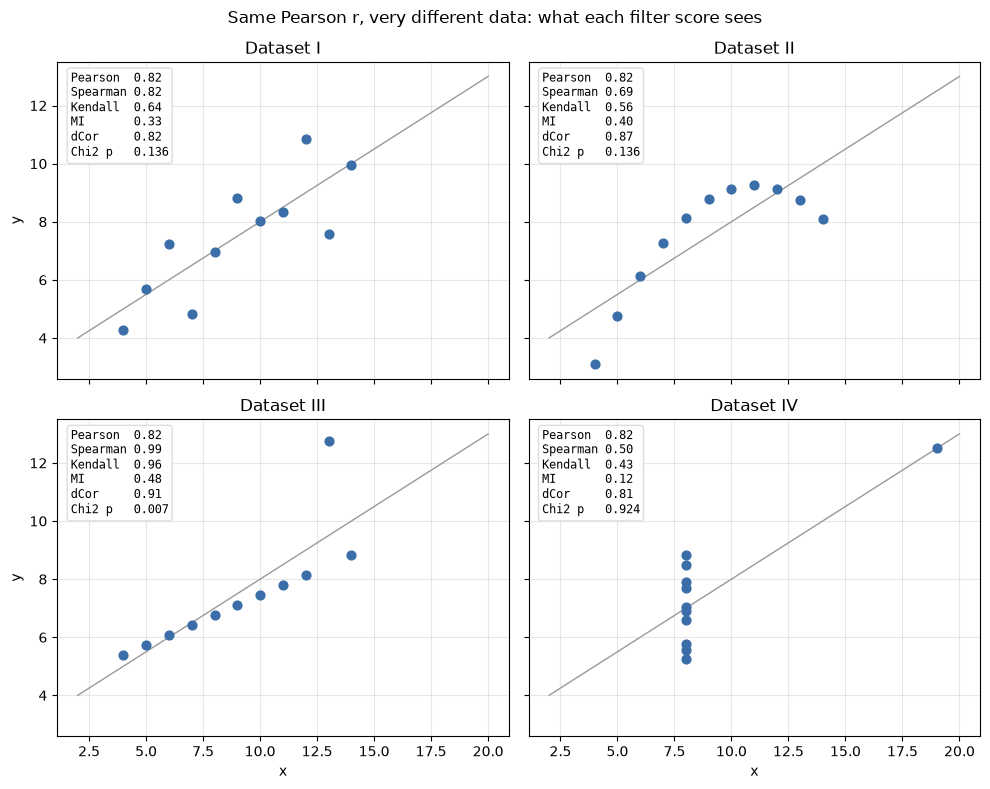

In [3]:
quartet_grid(df, scores);

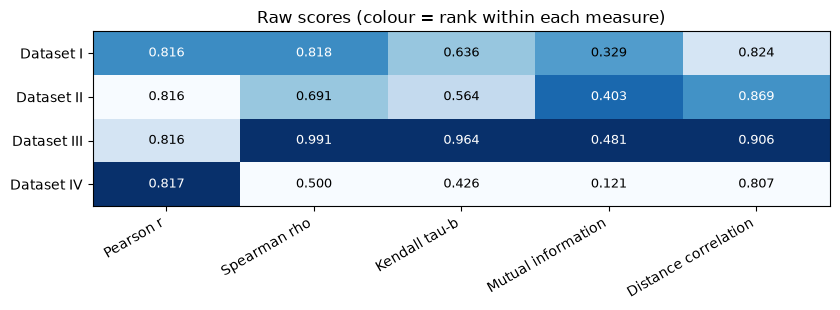

In [4]:
score_heatmap(scores, list(SCORES));

**What stands out**

* **Pearson** cannot separate the four datasets at all, which is the point of the quartet.
* **Distance correlation** also stays in a narrow band (0.81 to 0.91). It detects dependence in all
  four, but by itself it would not warn you that IV is driven by one point.
* **Spearman and Kendall** separate them. They rank III highest (the outlier barely affects ranks)
  and IV lowest (ten tied x values).
* **Mutual information** gives IV by far the lowest score, which is sensible because x carries almost no
  information about y apart from one point.
* **Chi-square after a median split** gives I and II *identical* scores. Binarising removes the
  curvature of II entirely.

## 2. Is the chi-square test even valid here?

With 11 observations split into a 2x2 table, most expected cell counts are below 5, which is the usual
rule of thumb for the chi-square approximation. Fisher's exact test is the appropriate alternative, and
it gives noticeably different p-values:

In [5]:
scores[['Chi-square', 'Chi-square p', 'Fisher exact p']]

,Chi-square,Chi-square p,Fisher exact p
dataset,,,
I,2.227,0.136,0.080
II,2.227,0.136,0.080
III,7.336,0.007,0.002
IV,0.009,0.924,0.455


For datasets I and II the chi-square p-value is 0.136, while Fisher's exact p-value is 0.080.
Any significance-threshold-based selection rule would be sensitive to this choice.

## 3. Mutual information is noisy at small n

scikit-learn's k-NN mutual-information estimator adds random jitter to break ties, so the value depends
on `random_state`. Across 50 seeds:

In [6]:
pd.DataFrame({name: mutual_information_spread(g['x'], g['y'], seeds=50)
              for name, g in df.groupby('dataset')}, index=['mean', 'std']).T

,mean,std
I,0.350,0.018
II,0.401,0.022
III,0.495,0.015
IV,0.086,0.025


The seed-to-seed standard deviation is about 0.02. That is small next to the gap between IV and the
rest, but comparable to the gap between I and II. With one fixed seed you could rank I and II
either way round.

## 4. How much does one point matter? (leave-one-out)

For each measure we drop one observation at a time and record the smallest and largest score.
A wide spread means the score hinges on a single observation.

In [7]:
rows = []
for name, g in df.groupby('dataset'):
    for measure, fn in SCORES.items():
        lo, hi, undefined = leave_one_out_range(g['x'], g['y'], fn)
        rows.append(dict(dataset=name, measure=measure, spread=hi - lo, undefined=undefined))
loo = pd.DataFrame(rows)
loo.pivot(index='measure', columns='dataset', values='spread')

dataset,I,II,III,IV
measure,,,,
Distance correlation,0.109,0.100,0.114,0.052
Kendall tau-b,0.178,0.267,0.044,0.000
Mutual information,0.230,0.324,0.507,0.033
Pearson r,0.134,0.132,0.208,0.049
Spearman rho,0.133,0.255,0.012,0.000


In [8]:
loo.pivot(index='measure', columns='dataset', values='undefined')

dataset,I,II,III,IV
measure,,,,
Distance correlation,0,0,0,1
Kendall tau-b,0,0,0,1
Mutual information,0,0,0,1
Pearson r,0,0,0,1
Spearman rho,0,0,0,1


* In **dataset IV**, removing the single point at x = 19 makes x constant, and every score becomes
  **undefined**: the whole relationship rests on one observation. None of the full-sample scores
  shows this.
* In **dataset III**, Pearson jumps from 0.82 to 1.00 when the outlier is removed, whereas
  Spearman and Kendall barely move (spread of 0.01 to 0.04).
* **Mutual information** is the least stable measure on dataset III, with a spread of about 0.5. The k-NN estimator
  is strongly affected by which points are neighbours when n is this small.

## Takeaways for feature selection

1. No single filter score is enough on its own. Pearson and distance correlation both rate all four
   datasets as roughly equally good features.
2. Rank-based scores (Spearman, Kendall) resist outliers but miss non-monotonic structure.
3. Discretising (median split followed by chi-square) throws away shape information, and the
   chi-square approximation is unreliable at small n. Use Fisher's exact test there.
4. Mutual-information estimates vary with the random seed and with individual points at small n. Average
   over several seeds, and treat small-sample MI rankings with caution.
5. A cheap leave-one-out check exposes features whose relevance depends on a single observation.

*Data:* F. J. Anscombe, "Graphs in Statistical Analysis", *The American Statistician* 27(1), 1973.